Analyzing bank credit customers to determine risk and find determining factors for higher credit risk levels

In [ ]:
# importing necessary libraries and loading the dataset
import pandas as pd

df = pd.read_csv('../data/german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [ ]:
# Checking for missing values
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
dtypes: int64(5), str(5)
memory usage: 78.3 KB


Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='str')

In [5]:
# Fill missing values in 'Saving accounts' and 'Checking account' with 'none'
df['Saving accounts'] = df['Saving accounts'].fillna('none')
df['Checking account'] = df['Checking account'].fillna('none')

In [6]:
# Check the data again after filling missing values
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   1000 non-null   str  
 6   Checking account  1000 non-null   str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
dtypes: int64(5), str(5)
memory usage: 78.3 KB


Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='str')

In [7]:
# Creating a simple risk score based on credit amount, duration, and account status
df['risk_score'] = (
    (df['Credit amount'] > df['Credit amount'].median()).astype(int) +
    (df['Duration'] > df['Duration'].median()).astype(int) +
    (df['Saving accounts'].isin(['little', 'none'])).astype(int) +
    (df['Checking account'].isin(['little', 'none'])).astype(int)
)

In [8]:
# Analyze the distribution of the risk score
df['risk_score'].value_counts()

risk_score
2    342
3    272
4    185
1    168
0     33
Name: count, dtype: int64

In [9]:
# Profiling the risk score by age, credit amount, and duration
risk_profile = df.groupby('risk_score')[['Age', 'Credit amount', 'Duration']].mean()
print(risk_profile)

                  Age  Credit amount   Duration
risk_score                                     
0           35.575758    1237.242424  11.484848
1           35.345238    1407.523810  12.029762
2           35.380117    2313.169591  16.245614
3           35.613971    4282.985294  25.172794
4           35.929730    5610.210811  32.972973


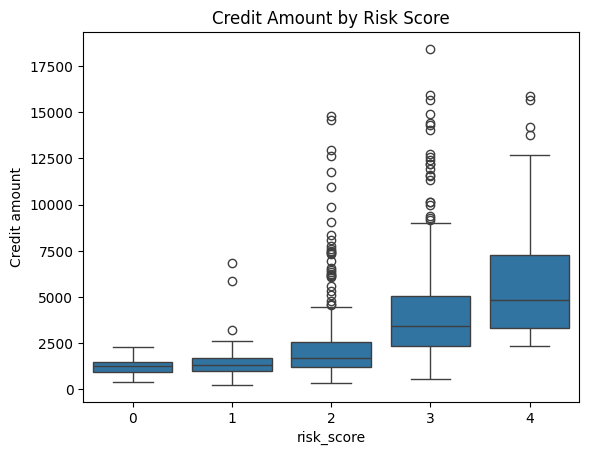

In [10]:
# Visualing the risk score using boxplot for Credit amount by Risk Score
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='risk_score', y='Credit amount', data=df)
plt.title('Credit Amount by Risk Score')
plt.show()

Higher risk profiles are associated with significantly larger loan amounts, with both median and variability increasing as risk score rises. This suggests that higher-risk borrowers tend to take on larger and more volatile credit exposures.

Text(0.5, 1.0, 'Average Risk Score by Housing Status')

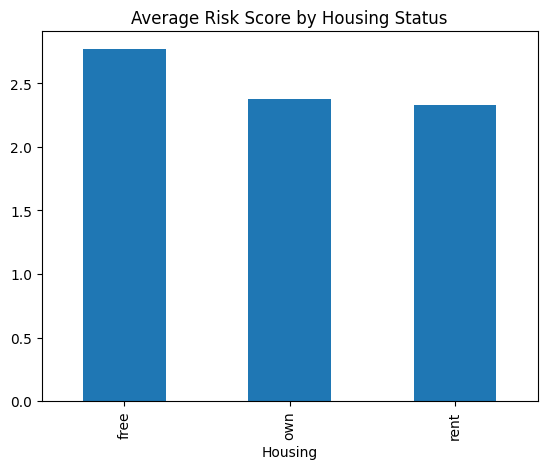

In [12]:
# Exploring insights by categorical variables
df.groupby('Housing')['risk_score'].mean().plot(kind='bar')
plt.title('Average Risk Score by Housing Status')

Customers with free housing exhibit higher average risk scores compared to those who own or rent, suggesting that lack of traditional housing financial obligations may correlate with weaker financial profiles or reduced credit stability. Could also reflect non-traditional financial situations, not necessarily “worse borrowers”

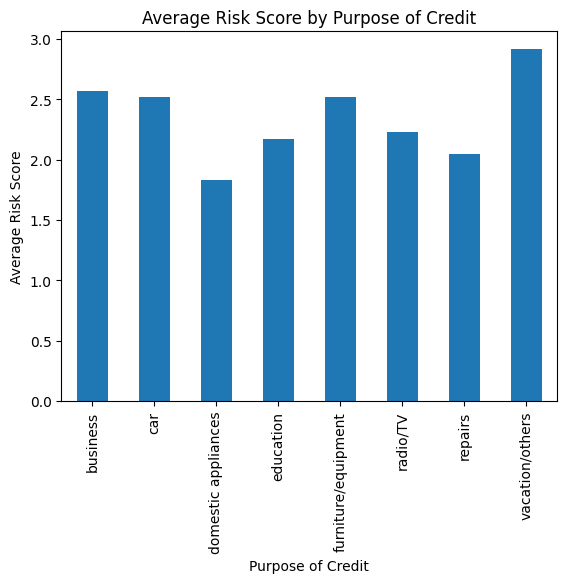

In [13]:
df.groupby('Purpose')['risk_score'].mean().plot(kind='bar')
plt.title('Average Risk Score by Purpose of Credit')
plt.xlabel('Purpose of Credit')
plt.ylabel('Average Risk Score')
plt.show()

In [14]:
# Creating risk categories based on the risk score
df['risk_level'] = pd.cut(
    df['risk_score'],
    bins=[-1, 1, 2, 4],
    labels=['Low', 'Medium', 'High']
)

In [16]:
# Analyze the distribution of risk levels
counts = df['risk_level'].value_counts()
percent = df['risk_level'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'count': counts,
    'percent': percent.round(2)
})

summary

,count,percent
risk_level,,
High,457,45.7
Medium,342,34.2
Low,201,20.1


Loan purpose appears to significantly influence risk profile, with discretionary spending categories such as vacation and business loans showing higher risk scores, while essential or smaller-scale purchases like domestic appliances and repairs are associated with lower risk.

Overall, higher-risk borrower profiles are characterized by larger loan amounts, longer durations, and weaker financial account indicators. Additionally, discretionary loan purposes and certain housing situations are associated with elevated risk levels, highlighting the importance of both financial behavior and borrower context in credit risk assessment.